# Transport rate plot

Index(['Gamma', 'Q', 'Sources'], dtype='object')
a = 13.72964076601551
b = 0.27168336673790927
c = 1.0


/tmp/ipykernel_127/2524112982.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=[-1.0, -1.0, 1.0])
/tmp/ipykernel_127/2524112982.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


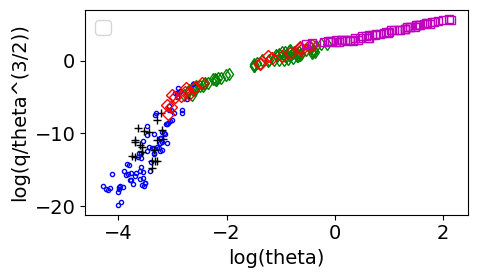

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# read file
df = pd.read_csv('data.csv')

# check column names
print(df.columns)

# extract columns
Gamma = df['Gamma'].values
Q = df['Q'].values
sources = df['Sources'].values

c=1
y = np.log(Q)
x = np.log(Gamma)
# model

def model(x, a, b, c):
    return a + ( -b/ (np.exp(x))** 1  ) +1.5*x

# fit
popt, pcov = curve_fit(model, x, y, p0=[-1.0, -1.0, 1.0])
a_fit, b_fit, c_fit = popt

print("a =", np.exp(a_fit) )
print("b =", b_fit)
print("c =", c_fit)

# fitted curve
x_plot = np.linspace(-4, 2, 100) 
y_fit = model(x_plot, a_fit, b_fit, c_fit)

# plot
plt.figure(figsize=(5, 3))

# marker styles (extend if needed)
markers = ['d', '.', '+', 'D', 's', 'P', 'X', '*']
colors = ['g', 'b', 'k', 'r', 'm', 'c', 'orange', 'purple']
for i, src in enumerate(unique_sources):
    mask = sources == src
    plt.plot(
        np.log(Gamma[mask]),
        np.log(Q[mask]),
        linestyle='None',
        marker=markers[i % len(markers)],
        color=colors[i % len(colors)],
        markerfacecolor='none',
    )

#plt.plot(x_plot, y_fit, 'k--', linewidth=2.5, label=f'fit: y={np.exp(a_fit):.3g} exp({b_fit:.3g} x^ { c_fit:.3g})')
plt.xlabel('log(theta)')
plt.ylabel('log(q/theta^(3/2))')
plt.legend()
# plt.ylim([-10, 3])
# plt.xlim([-2, 1])
plt.tight_layout()
plt.show()

Index(['Gamma', 'Q', 'Sources'], dtype='object')


/tmp/ipykernel_127/32121320.py:42: RuntimeWarning: invalid value encountered in power
  q3 = 10* (gammap-0.04)**1.5


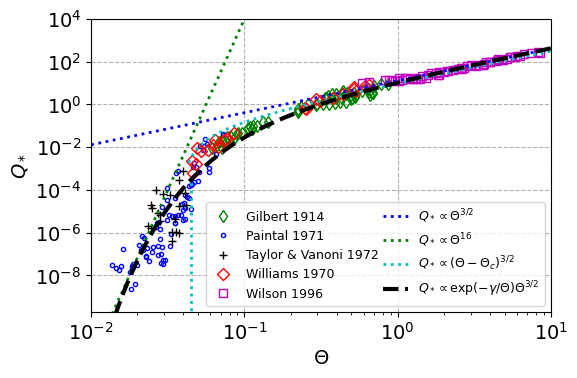

In [2]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# read file
df = pd.read_csv('data.csv')

# check column names
print(df.columns)

# extract columns
Gamma = df['Gamma'].values
Q = df['Q'].values
sources = df['Sources'].values

# unique sources
unique_sources = np.unique(sources)

# marker styles (extend if needed)
markers = ['d', '.', '+', 'D', 's', 'P', 'X', '*']
colors = ['g', 'b', 'k', 'r', 'm', 'c', 'orange', 'purple']

plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})

for i, src in enumerate(unique_sources):
    mask = sources == src
    plt.loglog(
        Gamma[mask],
        Q[mask],
        linestyle='None',
        marker=markers[i % len(markers)],
        color=colors[i % len(colors)],
        markerfacecolor='none',
        label=src
    )

gammap = np.logspace(-2, 1.5, 100) 
q1 = 13 * (gammap)**1.5
q2 = 1e20* gammap**16
q3 = 10* (gammap-0.04)**1.5

plt.loglog(gammap, q1, 'b:', linewidth=2, markerfacecolor='none', label=r'$Q_* \propto \Theta^{3/2}$')
plt.loglog(gammap, q2, 'g:', linewidth=2, markerfacecolor='none', label=r'$Q_* \propto\Theta^{16}$')
plt.loglog(gammap, q3, 'c:', linewidth=2, markerfacecolor='none', label=r'$Q_* \propto (\Theta-\Theta_c)^{3/2}$')
plt.loglog([0.045,0.045], [1e-10, 3e-4], 'c:', linewidth=2 )

           
#Qp=13.7 * gammap**1.5 *np.exp(-0.272/ gammap)
Qp=np.exp(a_fit) * gammap**1.5 *np.exp(-b_fit/ gammap**c_fit)
plt.loglog(gammap, Qp, 'k--', linewidth=3, markerfacecolor='none', label=r'$Q_* \propto \exp(-\gamma/\Theta)\Theta^{3/2}$')


plt.ylim([2e-10, 1e4])
plt.xlim([1e-2, 1e1])
plt.xlabel(r'$\Theta$')
plt.ylabel(r'$Q_*$')
plt.legend(frameon=True, fontsize=9, ncol=2, columnspacing=0.4)
plt.grid(True, which="major", ls="--")
plt.tight_layout()
plt.savefig('fig1.pdf', dpi=300, bbox_inches='tight')
plt.show()